# Filtro anti-haters — classificazione multi-label di commenti tossici

**Obiettivo:** riconoscere automaticamente i commenti offensivi e assegnarli a una o più delle sei categorie
`toxic`, `severe_toxic`, `obscene`, `threat`, `insult`, `identity_hate` (dataset Jigsaw/Wikipedia, ~160.000 commenti).

**Vincolo di progetto:** niente architetture Transformer → rete **Bidirectional LSTM** con embedding **Word2Vec** pre-addestrati.

**Pipeline:** pulizia del testo → split train/val/test → tokenizzazione (fit solo sul train) → pesi per le classi minoritarie →
tuning degli iperparametri (Keras Tuner) → addestramento → **soglie di decisione ottimizzate per classe** → valutazione → funzione di inferenza.

---
### Note di revisione (v2)
| # | Problema nella versione precedente | Correzione |
|---|---|---|
| 1 | `clean_text` rimuoveva gli a-capo senza sostituirli con uno spazio → parole fuse (`"explanationwhy"`) | a-capo e punteggiatura sostituiti con spazio |
| 2 | ID del dataset nella variabile diverso da quello usato nel comando `gdown` | un solo ID, usato ovunque |
| 3 | `input()` interattivo → il notebook non girava da inizio a fine | flag `LOAD_EXISTING_MODEL` nella configurazione |
| 4 | Keras Tuner ricaricava una ricerca precedente invece di eseguirla | `overwrite=True` + flag `RUN_TUNING` |
| 5 | Tokenizer addestrato su tutto il dataset prima dello split (leakage del vocabolario) | split prima, tokenizer adattato solo sul training set |
| 6 | Soglia fissa 0.5 per tutte le classi | soglia per classe scelta sul validation set (max F1) |
| 7 | Metrica `accuracy` poco significativa in multi-label | ROC AUC multi-label in training; report con F1, ROC AUC, exact match |
| 8 | Analisi negazioni: cercava `"don't"` in testo senza apostrofi e usava sottostringhe (`"no"` dentro `"know"`) | ricerca per parola intera sulle forme pulite |
| 9 | Solo il modello veniva copiato su Drive: tokenizer perso al riavvio | salvati insieme modello, tokenizer, soglie e configurazione |
| 10 | Uso di `exit()`, numerazione sezioni incompleta, costruzione del modello duplicata | eccezioni esplicite, un'unica funzione `build_model` |
| 11 | Checkpoint e early stopping sulla `val_loss` (pesata in training, non in validazione) | monitor su `val_auc`: selezione del modello coerente con la metrica |

> ⚠️ Il modello salvato in precedenza è stato addestrato con la vecchia pulizia del testo: **va riaddestrato** (runtime GPU consigliato).

In [24]:
# Librerie non sempre presenti in Colab
%pip install -q gensim keras-tuner gdown

## 0. Configurazione

In [25]:
import os, re, json, string, pickle, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras_tuner as kt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, classification_report, roc_auc_score,
                             accuracy_score, hamming_loss)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# --- Dati ---
DATASET_DRIVE_PATH = '/content/drive/MyDrive/Filter_Toxic_Comments_dataset.csv'  # copia del CSV nel tuo Drive
DATASET_FILE_ID = '1upy1iBjIoPT35MN5JtnfRlDwye3JmJBn'   # alternativa: link pubblico (non più attivo a settembre 2026)
WORK_DIR        = '/tmp/filtro_anti_haters'
DATASET_PATH    = os.path.join(WORK_DIR, 'Filter_Toxic_Comments_dataset.csv')
ARTIFACT_DIR    = os.path.join(WORK_DIR, 'artifacts')        # modello, tokenizer, soglie
SAMPLE_FRAC     = 1.0      # <1.0 per prove veloci su un sottoinsieme

# --- Flusso di esecuzione ---
LOAD_EXISTING_MODEL = False   # True = carica modello/tokenizer/soglie da DRIVE_FOLDER e salta l'addestramento
RUN_TUNING          = False   # False = usa DEFAULT_HP (risultato del tuning precedente) e risparmia tempo
USE_WORD2VEC        = True    # False = embedding addestrato da zero (utile se la RAM non basta)
SAVE_TO_DRIVE       = True
DRIVE_FOLDER        = '/content/drive/MyDrive/modelli_addestrati/filtro_anti_haters'

# --- Iperparametri ---
LABEL_COLUMNS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
MAX_FEATURES  = 20000     # dimensione del vocabolario
MAX_LEN       = 200       # lunghezza delle sequenze dopo il padding
EMBEDDING_DIM = 300       # usato solo se USE_WORD2VEC=False (Word2Vec impone 300)
DEFAULT_HP    = {'lstm_units': 192, 'dropout_rate': 0.3}
TUNING_TRIALS = 5
TUNING_EPOCHS = 3
BATCH_SIZE    = 32
EPOCHS        = 10
RANDOM_STATE  = 42

os.makedirs(ARTIFACT_DIR, exist_ok=True)
tf.keras.utils.set_random_seed(RANDOM_STATE)

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Drive montato subito (dataset + salvataggio): l'autorizzazione viene chiesta all'inizio, non dopo un'ora di addestramento
if IN_COLAB and not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
print('Ambiente Colab:', IN_COLAB, '| GPU:', tf.config.list_physical_devices('GPU'))

Ambiente Colab: True | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Caricamento e ispezione dei dati

In [26]:
os.makedirs(WORK_DIR, exist_ok=True)
if not os.path.exists(DATASET_PATH):
    if os.path.exists(DATASET_DRIVE_PATH):
        shutil.copy(DATASET_DRIVE_PATH, DATASET_PATH)          # copia locale: lettura più veloce
        print('Dataset copiato da Drive.')
    else:
        import gdown
        if gdown.download(id=DATASET_FILE_ID, output=DATASET_PATH, quiet=False) is None:
            raise FileNotFoundError(f'Dataset non trovato: carica il CSV in {DATASET_DRIVE_PATH}')

df = pd.read_csv(DATASET_PATH, sep=',', quotechar='"', on_bad_lines='skip', encoding='utf-8')

missing = [c for c in ['comment_text'] + LABEL_COLUMNS if c not in df.columns]
if missing:
    raise ValueError(f'Colonne mancanti nel dataset: {missing}')

df = df.dropna(subset=['comment_text']).reset_index(drop=True)
if SAMPLE_FRAC < 1.0:
    df = df.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE).reset_index(drop=True)

print(f'Commenti: {len(df):,}')
display(df.head())

Commenti: 159,571


,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,sum_injurious
0,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,0
1,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,0
2,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,0
3,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,0
4,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,0


Commenti senza alcuna etichetta: 89.8%


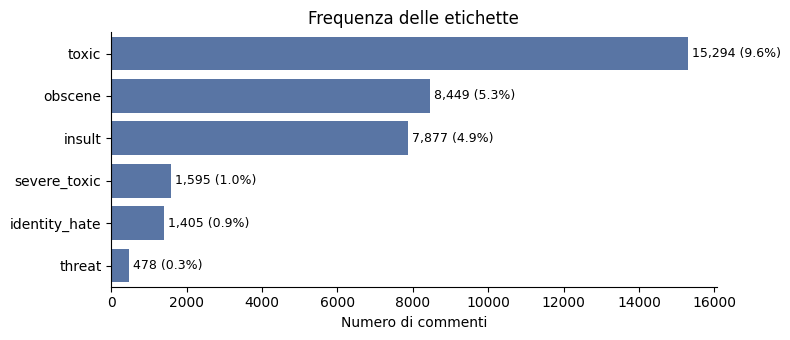

In [27]:
# Distribuzione delle etichette: il dataset è fortemente sbilanciato
label_counts = df[LABEL_COLUMNS].sum().sort_values(ascending=False)
clean_share = (df[LABEL_COLUMNS].sum(axis=1) == 0).mean()
print(f'Commenti senza alcuna etichetta: {clean_share:.1%}')

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.barplot(x=label_counts.values, y=label_counts.index, color='#4C72B0', ax=ax)
for i, v in enumerate(label_counts.values):
    ax.text(v, i, f' {v:,} ({v/len(df):.1%})', va='center', fontsize=9)
ax.set_xlabel('Numero di commenti'); ax.set_ylabel('')
ax.set_title('Frequenza delle etichette')
sns.despine(); plt.tight_layout(); plt.show()

## 2. Preprocessing

### 2.1 Pulizia del testo
Minuscolo, rimozione di URL, tag HTML, parole con numeri (es. indirizzi IP) e punteggiatura.
**Correzione v2:** a-capo e punteggiatura vengono sostituiti con uno spazio, non eliminati, così le parole adiacenti restano separate.
Gli apostrofi vengono rimossi senza spazio (`don't` → `dont`) per non spezzare le contrazioni.

In [28]:
_PUNCT_NO_APOS = string.punctuation.replace("'", "")

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)           # URL
    text = re.sub(r'<.*?>', ' ', text)                           # tag HTML
    text = re.sub(r'[\r\n\t]+', ' ', text)                       # a-capo -> spazio
    text = re.sub(r"[’`']", '', text)                            # apostrofi: don't -> dont
    text = re.sub(r'[%s]' % re.escape(_PUNCT_NO_APOS), ' ', text) # punteggiatura -> spazio
    text = re.sub(r'\w*\d\w*', ' ', text)                        # parole con numeri (IP, date...)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Test rapidi sui casi che nella v1 davano problemi
assert clean_text('Explanation\nWhy the edits') == 'explanation why the edits'
assert clean_text('"\nMore\nI can\'t') == 'more i cant'
assert clean_text('retired now.89.205.38.27') == 'retired now'
assert clean_text('see http://x.com/a?b=1 now') == 'see now'

df['cleaned_comment_text'] = df['comment_text'].apply(clean_text)
for i in range(3):
    print('Originale:', df['comment_text'].iloc[i][:200].replace('\n', '⏎'))
    print('Pulito:   ', df['cleaned_comment_text'].iloc[i][:200], '\n')

Originale: Explanation⏎Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove th
Pulito:    explanation why the edits made under my username hardcore metallica fan were reverted they werent vandalisms just closure on some gas after i voted at new york dolls fac and please dont remove the tem 

Originale: D'aww! He matches this background colour I'm seemingly stuck with. Thanks.  (talk) 21:51, January 11, 2016 (UTC)
Pulito:    daww he matches this background colour im seemingly stuck with thanks talk january utc 

Originale: Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the
Pulito:    hey man im really not trying to edit war its just that this guy is constantly removing relevant information and talking to me t

### 2.2 Suddivisione train / validation / test (80 / 10 / 10)
Lo split avviene **prima** della tokenizzazione: il vocabolario verrà costruito solo sul training set,
così validation e test restano davvero "dati mai visti".

In [29]:
x_all = df['cleaned_comment_text']
y_all = df[LABEL_COLUMNS].astype('float32')

x_train_text, x_temp_text, y_train, y_temp = train_test_split(
    x_all, y_all, test_size=0.2, random_state=RANDOM_STATE)
x_val_text, x_test_text, y_val, y_test = train_test_split(
    x_temp_text, y_temp, test_size=0.5, random_state=RANDOM_STATE)

split_summary = pd.DataFrame({
    'train': y_train.sum(), 'validation': y_val.sum(), 'test': y_test.sum()
}).astype(int)
split_summary.loc['n. commenti'] = [len(y_train), len(y_val), len(y_test)]
display(split_summary)

,train,validation,test
toxic,12238,1536,1520
severe_toxic,1274,159,162
obscene,6734,859,856
threat,404,37,37
insult,6263,806,808
identity_hate,1111,156,138
n. commenti,127656,15957,15958


### 2.3 Tokenizzazione e padding

In [30]:
TOKENIZER_PATH = os.path.join(ARTIFACT_DIR, 'tokenizer.pickle')

if LOAD_EXISTING_MODEL:
    for fname in ['best_model.keras', 'tokenizer.pickle', 'thresholds.json']:
        shutil.copy(os.path.join(DRIVE_FOLDER, fname), os.path.join(ARTIFACT_DIR, fname))
    with open(TOKENIZER_PATH, 'rb') as f:
        tokenizer = pickle.load(f)
    print('Tokenizer caricato da Drive.')
else:
    tokenizer = Tokenizer(num_words=MAX_FEATURES, oov_token='<unk>')
    tokenizer.fit_on_texts(x_train_text)                 # solo training set
    with open(TOKENIZER_PATH, 'wb') as f:
        pickle.dump(tokenizer, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f'Tokenizer adattato sul training set e salvato in {TOKENIZER_PATH}')

def to_padded(texts):
    return pad_sequences(tokenizer.texts_to_sequences(texts), maxlen=MAX_LEN,
                         padding='post', truncating='post')

x_train, x_val, x_test = to_padded(x_train_text), to_padded(x_val_text), to_padded(x_test_text)
print('Forme:', x_train.shape, x_val.shape, x_test.shape)

lengths = x_train_text.str.split().str.len()
print(f'Commenti più lunghi di MAX_LEN={MAX_LEN} parole: {(lengths > MAX_LEN).mean():.1%}')

Tokenizer adattato sul training set e salvato in /tmp/filtro_anti_haters/artifacts/tokenizer.pickle
Forme: (127656, 200) (15957, 200) (15958, 200)
Commenti più lunghi di MAX_LEN=200 parole: 6.3%


### 2.4 Pesi dei campioni per le classi minoritarie
Ogni commento parte da peso 1; per ogni etichetta positiva si aggiunge il rapporto negativi/positivi di quella classe.
I pesi vengono poi normalizzati a media 1, così la scala della loss non cambia.

In [31]:
sample_weights = np.ones(len(y_train))
for label in LABEL_COLUMNS:
    pos = (y_train[label] == 1).sum()
    neg = (y_train[label] == 0).sum()
    if pos > 0:
        sample_weights[(y_train[label] == 1).values] += neg / pos - 1.0
sample_weights = sample_weights / sample_weights.mean()
print(f'Pesi normalizzati → min {sample_weights.min():.3f} | max {sample_weights.max():.1f} | media {sample_weights.mean():.2f}')

Pesi normalizzati → min 0.152 | max 86.9 | media 1.00


## 3. Modello

### 3.1 Embedding Word2Vec pre-addestrati
Vettori `word2vec-google-news-300` (~1.6 GB da scaricare, ~3.6 GB in RAM). Dopo aver costruito la matrice il modello
Word2Vec viene liberato dalla memoria. Le parole non presenti in Word2Vec partono da un vettore casuale piccolo.

In [32]:
embedding_matrix = None
if USE_WORD2VEC and not LOAD_EXISTING_MODEL:
    try:
        import gensim.downloader as api
        w2v = api.load('word2vec-google-news-300')
        EMBEDDING_DIM = w2v.vector_size
        rng = np.random.default_rng(RANDOM_STATE)
        embedding_matrix = rng.normal(0, 0.05, (MAX_FEATURES + 1, EMBEDDING_DIM)).astype('float32')
        embedding_matrix[0] = 0.0                                   # token di padding
        found = 0
        for word, idx in tokenizer.word_index.items():
            if idx > MAX_FEATURES:
                continue
            if word in w2v.key_to_index:
                embedding_matrix[idx] = w2v[word]
                found += 1
        print(f'Copertura Word2Vec del vocabolario: {found / MAX_FEATURES:.1%}')
        del w2v
        import gc; gc.collect()
    except Exception as e:
        print(f'Word2Vec non disponibile ({e}). Si procede con embedding addestrato da zero.')
        embedding_matrix = None

Copertura Word2Vec del vocabolario: 89.8%


### 3.2 Architettura
`Embedding (Word2Vec, addestrabile)` → `BiLSTM` → `Dropout` → `BiLSTM` → `Dropout` → `Dense(6, sigmoid)`.
Un'unica funzione `build_model` serve sia al tuning sia al modello finale.

In [33]:
def build_model(hp):
    lstm_units   = hp.Int('lstm_units', min_value=64, max_value=256, step=64)
    dropout_rate = hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1)

    if embedding_matrix is not None:
        emb = tf.keras.layers.Embedding(
            MAX_FEATURES + 1, embedding_matrix.shape[1],
            embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
            trainable=True, name='embedding_word2vec')
    else:
        emb = tf.keras.layers.Embedding(MAX_FEATURES + 1, EMBEDDING_DIM, name='embedding')

    inputs = tf.keras.layers.Input(shape=(MAX_LEN,))
    x = emb(inputs)
    x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(lstm_units, return_sequences=True))(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(lstm_units))(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    outputs = tf.keras.layers.Dense(len(LABEL_COLUMNS), activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=[tf.keras.metrics.AUC(multi_label=True, num_labels=len(LABEL_COLUMNS), name='auc')])
    return model

### 3.3 Tuning degli iperparametri (Keras Tuner — Random Search)
Si cercano `lstm_units` e `dropout_rate` minimizzando la `val_loss`. La dimensione dell'embedding è fissata da Word2Vec.
Con `RUN_TUNING = False` si usano direttamente i valori migliori trovati in precedenza (`DEFAULT_HP`).

In [34]:
if LOAD_EXISTING_MODEL:
    print('Tuning saltato: si usa il modello salvato.')
elif RUN_TUNING:
    tuner = kt.RandomSearch(build_model, objective='val_loss', max_trials=TUNING_TRIALS,
                            executions_per_trial=1, overwrite=True, seed=RANDOM_STATE,
                            directory=os.path.join(WORK_DIR, 'keras_tuner'), project_name='toxic_comments')
    tuner.search(x_train, y_train.values, epochs=TUNING_EPOCHS, batch_size=BATCH_SIZE,
                 validation_data=(x_val, y_val.values), sample_weight=sample_weights, verbose=1)
    best_trial = tuner.oracle.get_best_trials(1)[0]
    if best_trial.score is None:
        raise RuntimeError('Tutti i trial del tuning sono falliti: controlla i messaggi di errore sopra.')
    best_hps = best_trial.hyperparameters
    print(f'Migliori iperparametri: {best_hps.values} (val_loss {best_trial.score:.4f})')
else:
    best_hps = kt.HyperParameters()
    best_hps.Fixed('lstm_units', DEFAULT_HP['lstm_units'])
    best_hps.Fixed('dropout_rate', DEFAULT_HP['dropout_rate'])
    print('Iperparametri fissati:', best_hps.values)

Iperparametri fissati: {'lstm_units': 192, 'dropout_rate': 0.3}


### 3.4 Addestramento del modello finale
Early stopping, checkpoint e riduzione del learning rate monitorano la **`val_auc`** (non la `val_loss`): con i pesi sui campioni la loss di training
e quella di validazione non sono confrontabili, e nel primo run la `val_loss` minima (epoca 7) corrispondeva a una AUC peggiore dell'epoca 3.

In [35]:
MODEL_PATH = os.path.join(ARTIFACT_DIR, 'best_model.keras')

if LOAD_EXISTING_MODEL:
    model = tf.keras.models.load_model(MODEL_PATH)
    history = None
    print('Modello caricato:', MODEL_PATH)
else:
    model = build_model(best_hps)
    model.summary()
    # Monitoriamo la val_auc (non la val_loss): la loss di training è pesata, quella di validazione no,
    # quindi la val_loss minima non coincide con il modello che separa meglio le classi.
    callbacks = [
        EarlyStopping(monitor='val_auc', mode='max', patience=3, restore_best_weights=True),
        ModelCheckpoint(MODEL_PATH, monitor='val_auc', mode='max', save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.2, patience=2, min_lr=1e-5, verbose=1),
    ]
    history = model.fit(x_train, y_train.values, batch_size=BATCH_SIZE, epochs=EPOCHS,
                        validation_data=(x_val, y_val.values), sample_weight=sample_weights,
                        callbacks=callbacks, verbose=2)
    model = tf.keras.models.load_model(MODEL_PATH)   # pesi del checkpoint migliore

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_word2vec (Embedding)  │ (None, 200, 300)       │     6,000,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 200, 384)       │       757,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 200, 384)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 384)            │       886,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         2,310 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,646,130 (29.17 MB)

 Trainable params: 7,646,130 (29.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10

Epoch 1: val_auc improved from None to 0.95467, saving model to /tmp/filtro_anti_haters/artifacts/best_model.keras

Epoch 1: finished saving model to /tmp/filtro_anti_haters/artifacts/best_model.keras
3990/3990 - 234s - 59ms/step - auc: 0.9124 - loss: 0.4109 - val_auc: 0.9547 - val_loss: 0.3227 - learning_rate: 0.0010
Epoch 2/10

Epoch 2: val_auc improved from 0.95467 to 0.97943, saving model to /tmp/filtro_anti_haters/artifacts/best_model.keras

Epoch 2: finished saving model to /tmp/filtro_anti_haters/artifacts/best_model.keras
3990/3990 - 230s - 58ms/step - auc: 0.9708 - loss: 0.3047 - val_auc: 0.9794 - val_loss: 0.1315 - learning_rate: 0.0010
Epoch 3/10

Epoch 3: val_auc improved from 0.97943 to 0.98115, saving model to /tmp/filtro_anti_haters/artifacts/best_model.keras

Epoch 3: finished saving model to /tmp/filtro_anti_haters/artifacts/best_model.keras
3990/3990 - 230s - 58ms/step - auc: 0.9819 - loss: 0.2622 - val_auc: 0.9811 - val_loss: 0.0880 - learning_rate: 0.001

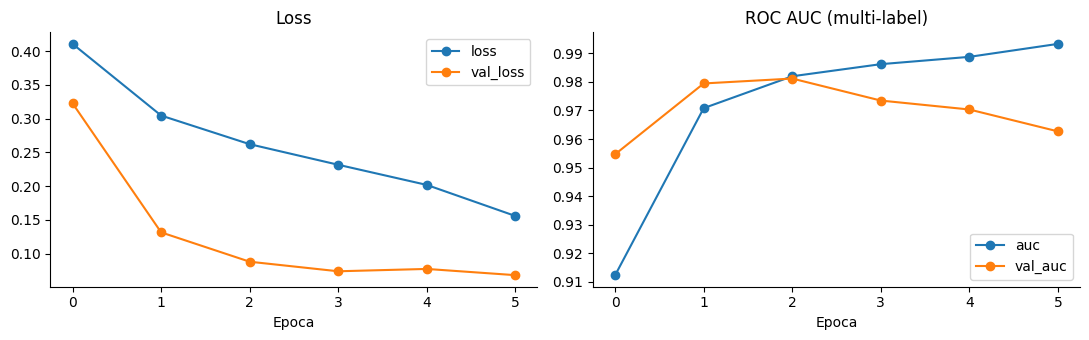

In [36]:
if history is not None:
    h = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    h[['loss', 'val_loss']].plot(ax=axes[0], marker='o', title='Loss')
    h[['auc', 'val_auc']].plot(ax=axes[1], marker='o', title='ROC AUC (multi-label)')
    for ax in axes:
        ax.set_xlabel('Epoca'); sns.despine(ax=ax)
    plt.tight_layout(); plt.show()

## 4. Valutazione

### 4.1 Soglie di decisione per classe
Con classi così sbilanciate la soglia 0.5 non è ottimale per tutte le etichette. Per ciascuna classe si sceglie la soglia
che massimizza l'F1 **sul validation set**; il test set resta intatto per la valutazione finale.

In [37]:
y_val_proba  = model.predict(x_val, batch_size=512, verbose=0)
y_test_proba = model.predict(x_test, batch_size=512, verbose=0)

def tune_thresholds(y_true, y_proba, grid=np.round(np.arange(0.05, 0.96, 0.01), 2)):
    best = {}
    for j, label in enumerate(LABEL_COLUMNS):
        scores = [f1_score(y_true[:, j], y_proba[:, j] >= t, zero_division=0) for t in grid]
        best[label] = float(grid[int(np.argmax(scores))])
    return best

THRESHOLDS_PATH = os.path.join(ARTIFACT_DIR, 'thresholds.json')
if LOAD_EXISTING_MODEL and os.path.exists(THRESHOLDS_PATH):
    with open(THRESHOLDS_PATH) as f:
        thresholds = json.load(f)
else:
    thresholds = tune_thresholds(y_val.values, y_val_proba)
    with open(THRESHOLDS_PATH, 'w') as f:
        json.dump(thresholds, f, indent=2)
print('Soglie per classe:', thresholds)

Soglie per classe: {'toxic': 0.81, 'severe_toxic': 0.49, 'obscene': 0.77, 'threat': 0.88, 'insult': 0.71, 'identity_hate': 0.84}


### 4.2 Metriche sul test set
- **ROC AUC** per classe: capacità di ordinare i commenti (indipendente dalla soglia; è la metrica della competizione Jigsaw).
- **Precision / Recall / F1** per classe, con soglia fissa 0.5 e con soglie ottimizzate.
- **Exact match ratio**: quota di commenti con *tutte e sei* le etichette corrette (nella v1 era chiamata "Overall Accuracy").

In [38]:
thr_vec = np.array([thresholds[l] for l in LABEL_COLUMNS])
y_true  = y_test.values.astype(int)
pred_05  = (y_test_proba >= 0.5).astype(int)
pred_opt = (y_test_proba >= thr_vec).astype(int)

rows = []
for j, label in enumerate(LABEL_COLUMNS):
    rows.append({
        'classe': label, 'supporto': int(y_true[:, j].sum()),
        'ROC AUC': roc_auc_score(y_true[:, j], y_test_proba[:, j]) if y_true[:, j].any() else np.nan,
        'F1 @0.5': f1_score(y_true[:, j], pred_05[:, j], zero_division=0),
        'soglia': thresholds[label],
        'F1 @soglia': f1_score(y_true[:, j], pred_opt[:, j], zero_division=0),
    })
per_class = pd.DataFrame(rows).set_index('classe')
display(per_class.style.format({'ROC AUC': '{:.3f}', 'F1 @0.5': '{:.3f}', 'soglia': '{:.2f}', 'F1 @soglia': '{:.3f}'}))

summary = pd.DataFrame({
    'soglia 0.5':       [f1_score(y_true, pred_05, average=a, zero_division=0) for a in ['micro', 'macro']]
                        + [accuracy_score(y_true, pred_05), hamming_loss(y_true, pred_05)],
    'soglie per classe': [f1_score(y_true, pred_opt, average=a, zero_division=0) for a in ['micro', 'macro']]
                        + [accuracy_score(y_true, pred_opt), hamming_loss(y_true, pred_opt)],
}, index=['F1 micro', 'F1 macro', 'Exact match ratio', 'Hamming loss'])
display(summary.round(4))
print(f"ROC AUC medio (macro): {np.nanmean(per_class['ROC AUC']):.4f}")

print('\nClassification report — soglie per classe')
print(classification_report(y_true, pred_opt, target_names=LABEL_COLUMNS, zero_division=0))

,supporto,ROC AUC,F1 @0.5,soglia,F1 @soglia
classe,,,,,
toxic,1520,0.970,0.677,0.81,0.764
severe_toxic,162,0.988,0.527,0.49,0.522
obscene,856,0.989,0.766,0.77,0.801
threat,37,0.982,0.213,0.88,0.408
insult,808,0.982,0.668,0.71,0.716
identity_hate,138,0.969,0.313,0.84,0.417


,soglia 0.5,soglie per classe
F1 micro,0.6500,0.7261
F1 macro,0.5273,0.6047
Exact match ratio,0.8621,0.9071
Hamming loss,0.0346,0.0210


ROC AUC medio (macro): 0.9801

Classification report — soglie per classe
               precision    recall  f1-score   support

        toxic       0.77      0.76      0.76      1520
 severe_toxic       0.46      0.61      0.52       162
      obscene       0.81      0.80      0.80       856
       threat       0.32      0.57      0.41        37
       insult       0.66      0.79      0.72       808
identity_hate       0.33      0.56      0.42       138

    micro avg       0.70      0.76      0.73      3521
    macro avg       0.56      0.68      0.60      3521
 weighted avg       0.72      0.76      0.73      3521
  samples avg       0.06      0.07      0.06      3521



### 4.3 Comportamento con le negazioni
Si estraggono dal test set commenti che contengono una negazione (ricerca per **parola intera** sul testo pulito,
dove `don't` è diventato `dont`) e si confrontano etichette reali e predette.

In [39]:
NEGATIONS = ['not', 'no', 'never', 'nothing', 'dont', 'doesnt', 'didnt', 'isnt', 'wasnt', 'werent',
             'havent', 'hasnt', 'hadnt', 'cant', 'couldnt', 'wont', 'wouldnt', 'shouldnt', 'aint']
neg_pattern = re.compile(r'\b(?:' + '|'.join(NEGATIONS) + r')\b')

has_neg = x_test_text.str.contains(neg_pattern).values
print(f'Commenti del test set con negazioni: {has_neg.sum():,} ({has_neg.mean():.1%})')

# F1 micro con e senza negazioni: il modello è meno affidabile quando c'è una negazione?
for name, mask in [('con negazione', has_neg), ('senza negazione', ~has_neg)]:
    print(f"  F1 micro {name}: {f1_score(y_true[mask], pred_opt[mask], average='micro', zero_division=0):.3f}")

# Esempi: metà tossici e metà no, per vedere entrambi i casi
idx_neg = np.where(has_neg)[0]
toxic_mask = y_true[idx_neg].any(axis=1)
examples = np.concatenate([idx_neg[toxic_mask][:5], idx_neg[~toxic_mask][:5]])
for i in examples:
    original = df.loc[x_test_text.index[i], 'comment_text'].replace('\n', ' ')[:180]
    real = [l for l, v in zip(LABEL_COLUMNS, y_true[i]) if v]
    pred = [l for l, v in zip(LABEL_COLUMNS, pred_opt[i]) if v]
    flag = '✅' if real == pred else '❌'
    print(f'\n{flag} {original}\n   reale: {real or "—"} | predetto: {pred or "—"}')

Commenti del test set con negazioni: 8,349 (52.3%)
  F1 micro con negazione: 0.692
  F1 micro senza negazione: 0.748

❌ you can't keep me down nigger  you can't keep me down nigger  you can't keep me down nigger  you can't keep me down nigger  you can't keep me down nigger  you can't keep me down ni
   reale: ['toxic', 'severe_toxic', 'insult', 'identity_hate'] | predetto: ['toxic', 'severe_toxic', 'obscene', 'insult', 'identity_hate']

❌ A bunch of non-academic clowns are now censoring the info, so I'm wasting my breath talking to morons. IMO  You and everyone deleting the 8 Prime Spirals are all LIARS the original
   reale: ['toxic', 'insult'] | predetto: —

❌ Uh, yeah it does, dumbass. Haven't you ever edited an article before to make it wordier and harder to understand?
   reale: ['toxic', 'insult'] | predetto: ['toxic']

❌ Don't Threaten Me! You are in VIOLATION of several wikipedia rules. You little B-ITCH!
   reale: ['toxic', 'obscene', 'insult'] | predetto: ['toxic']

❌ I agree

## 5. Salvataggio degli artefatti su Google Drive
Modello, tokenizer, soglie e configurazione vengono salvati insieme: servono tutti e quattro per usare il filtro in produzione.

In [40]:
config = {'LABEL_COLUMNS': LABEL_COLUMNS, 'MAX_FEATURES': MAX_FEATURES, 'MAX_LEN': MAX_LEN,
          'hyperparameters': best_hps.values if not LOAD_EXISTING_MODEL else None}
with open(os.path.join(ARTIFACT_DIR, 'config.json'), 'w') as f:
    json.dump(config, f, indent=2)

if SAVE_TO_DRIVE and IN_COLAB and not LOAD_EXISTING_MODEL:
    os.makedirs(DRIVE_FOLDER, exist_ok=True)
    for fname in os.listdir(ARTIFACT_DIR):
        shutil.copy(os.path.join(ARTIFACT_DIR, fname), os.path.join(DRIVE_FOLDER, fname))
    print('Artefatti copiati in', DRIVE_FOLDER, '→', os.listdir(DRIVE_FOLDER))
else:
    print('Artefatti locali:', os.listdir(ARTIFACT_DIR))

Artefatti copiati in /content/drive/MyDrive/modelli_addestrati/filtro_anti_haters → ['best_model.keras', 'thresholds.json', 'config.json', 'tokenizer.pickle']


## 6. Inferenza su nuovi commenti
Funzione autonoma: carica gli artefatti dalla cartella indicata e restituisce, per ogni etichetta, probabilità ed esito.
È la base per la demo web (es. Gradio su Hugging Face Spaces).

In [41]:
class ToxicityFilter:
    def __init__(self, artifact_dir):
        self.model = tf.keras.models.load_model(os.path.join(artifact_dir, 'best_model.keras'))
        with open(os.path.join(artifact_dir, 'tokenizer.pickle'), 'rb') as f:
            self.tokenizer = pickle.load(f)
        with open(os.path.join(artifact_dir, 'thresholds.json')) as f:
            self.thresholds = json.load(f)
        with open(os.path.join(artifact_dir, 'config.json')) as f:
            cfg = json.load(f)
        self.labels, self.max_len = cfg['LABEL_COLUMNS'], cfg['MAX_LEN']

    def predict(self, comments):
        if isinstance(comments, str):
            comments = [comments]
        seq = self.tokenizer.texts_to_sequences([clean_text(c) for c in comments])
        proba = self.model.predict(pad_sequences(seq, maxlen=self.max_len, padding='post', truncating='post'), verbose=0)
        out = pd.DataFrame(proba, columns=self.labels)
        out.insert(0, 'commento', comments)
        out['etichette'] = [[l for l in self.labels if row[l] >= self.thresholds[l]] for _, row in out.iterrows()]
        out['tossico'] = out['etichette'].str.len() > 0
        return out

toxicity_filter = ToxicityFilter(ARTIFACT_DIR)

In [42]:
examples = [
    "This is a great comment, not toxic at all.",
    "You are an idiot! I will kill you.",
    "This is so stupid, why would you even say that?",
    "I don't find this offensive.",
    "Thanks for fixing the references, the article reads much better now.",
]
result = toxicity_filter.predict(examples)
display(result.style.format({l: '{:.2f}' for l in LABEL_COLUMNS})
        .background_gradient(subset=LABEL_COLUMNS, cmap='Reds', vmin=0, vmax=1))

,commento,toxic,severe_toxic,obscene,threat,insult,identity_hate,etichette,tossico
0,"This is a great comment, not toxic at all.",0.08,0.00,0.01,0.01,0.02,0.01,[],False
1,You are an idiot! I will kill you.,1.00,0.27,0.98,0.93,0.97,0.19,"['toxic', 'obscene', 'threat', 'insult']",True
2,"This is so stupid, why would you even say that?",0.95,0.05,0.58,0.02,0.86,0.19,"['toxic', 'insult']",True
3,I don't find this offensive.,0.21,0.01,0.03,0.03,0.03,0.02,[],False
4,"Thanks for fixing the references, the article reads much better now.",0.02,0.00,0.01,0.00,0.01,0.00,[],False
